# Scientific Computing Project #3

---------------

**Author:** *Salvador Palma* (mtr765) <br>
**Institution:** UCPH - University of Copenhagen

## Week 4

### Exercise a)

#### (1)

The function `calculatePotential1(x)` takes in a scalar `x` to construct the vectors $x_0 = [x,0,0]$ and $x_1 = [0,0,0]$ that are fed into `V(points)` to calcualte the Lennard-Jones potential at $\sigma = 3.401$ and $\epsilon = 0.997$. The function is then used to plot 100 points ranging from 3 to 11, which result is observable in the output cell below.

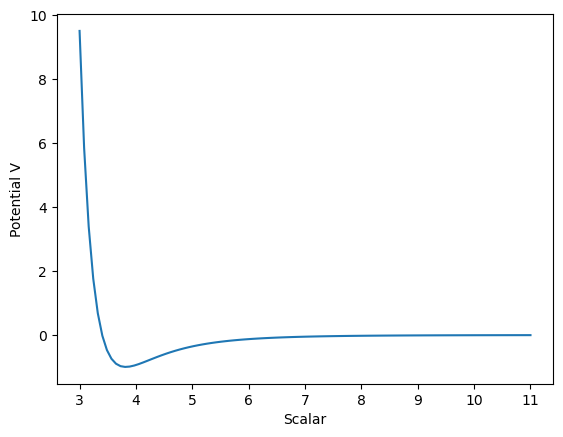

In [31]:
from LJhelperfunctions import *
import numpy as np
import matplotlib.pyplot as plt

def calculatePotential1(x):
    x0 = np.array([x, 0, 0])
    x1  = np.array([0, 0, 0])
    points = np.array([x0, x1])
    return V(points)


x = np.linspace(3, 11, 100)
y = [calculatePotential1(xi) for xi in x]

plt.plot(x, y)
plt.xlabel('Scalar')
plt.ylabel('Potential V')
plt.show()


#### (2)

In a similar manner as the previous exercise, `calculatePotential2(x)` takes in a scalar argument `x` and computes the potential but this time on the added points $x_2 = [14,0,0]$ and $x_3 = [7, 3.2, 0]$. Again, the resulting values for the same linear space as the exercise above is displayed in the output cell below.

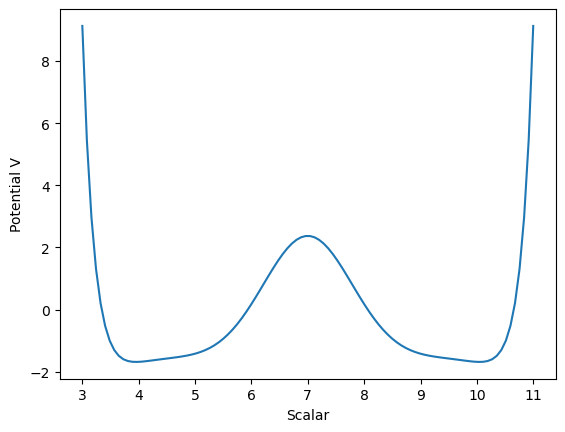

In [30]:
def calculatePotential2(x):
    x0 = np.array([x, 0, 0])
    x1  = np.array([0, 0, 0])
    x2 = np.array([14, 0, 0])
    x3 = np.array([7, 3.2, 0])
    points = np.array([x0, x1, x2, x3])
    return V(points)

x = np.linspace(3, 11, 100)
y = [calculatePotential2(xi) for xi in x]

plt.plot(x, y)
plt.xlabel('Scalar')
plt.ylabel('Potential V')
plt.show()

### Exercise b)

The *Bisection Root* algorithm is at its core, a sort of binary search algorithm running across a continous function $f$ in order to find a zero within the interval $[a, b]$. Therefore, the algorithm is pretty straightforward and can be found below in the function `bisection_root(f, a, b, tolerance)`. Running this utilizing the function from exercise a1) for the initial interval $[2,6]$ yields $x=\sigma$ with an error $\lt 10^{-13}$ in 46 calls to function $f$.


In [59]:

def bisection_root(f, a, b, tolerance=1e-13):
    assert f(a) * f(b) < 0

    y1 = f(a)
    n = 1

    while (b - a) / 2 > tolerance:

        midpoint = (a + b) / 2
        y_mid = f(midpoint)
        n += 1
        if y_mid == 0:
            return midpoint
        elif y1 * y_mid < 0:
            b = midpoint
        else:
            a = midpoint
            y1 = y_mid
 
    return (a + b) / 2, n

x, n_calls = bisection_root(calculatePotential1, 2, 6)
print(f"x={x}, n_calls={n_calls}")

x=3.4010000000000105, n_calls=46


### Exercise c)

With the *Newton-Raphson* algorithm, the approximation is continuously updated by by:
$$x_{k+1} = x_k - \frac{f(x_k)}{f'(x_k)}$$

Just by the expression, we can see that if the derivative happens to vanish, the guess will sky-rocket, going out of bounds for $[a,b]$. That's the reason why the resulting `x`, returned within 26 calls to both $f$ and its derivative, has a much higher error margin than the bisection method. 

In [58]:
def newton_root(f, df, x0, tolerance, max_iterations):
    n = 0
    while n < max_iterations:
        x1 = x0 - f(x0) / df(x0)
        n += 2
        if abs(x1 - x0) < tolerance:
            return x1, n
        x0 = x1
    return x1, n

def derivative(r):
    return 4*EPSILON*(6*SIGMA**6/r**7 - 12*SIGMA**12/r**13)

x, n_calls = newton_root(calculatePotential1, derivative, 2, 1e-12, 100)
print(f"x={x}, n_calls={n_calls}")

x=3.4009999999999994, n_calls=26


### Exercise d)

We saw that *Bisection Root* is guaranteed to converge, however, *Newton-Raphson* method utilizes less calls. Utilizing a mix of these two allows us to get both of these benefits. 

The algorithm starts by a bisection root step before joining any loop. From here, we utilize Newton-Rapshon step to propose a new x, if this falls in between $[a,b]$, then we proceed with the suggestion; If not, we obtain the more certain step from bisection root. Lastly, it's a matter of checking for convergence and/or redefining the limits for the next iteration.

This algorithm returns an $x$ with an error $\lt 10^{-13}$ in merely 23 calls to both function $f$ and its derivative, which proves that we got the *guaranteed convergance* of bisection root, with the speed boost from newton-rapshon.

In [ ]:
def hybrid_root(f, df, a, b, tolerance, max_iterations):

    y_a = f(a)
    x = (a + b) / 2
    y = f(x)
    n = 2

    while n < max_iterations:

        x_newton = x - y / df(x)
        n += 1
        if a < x_newton < b:
            x = x_newton
        else:
            x = (a + b) / 2

        y = f(x)
        n += 1
        if abs(y) < tolerance:
            return x, n

        if y_a * y < 0:
            b = x
        else:
            a = x
            y_a = y

    return x, n

x, n_calls = hybrid_root(calculatePotential1, derivative, 2, 6, 1e-13, 100)
print(f"x={x}, n_calls={n_calls}")

x=3.4010000000000002, n_calls=23


### Exercise e)

The gradient obtained from the same particle system as exercise a1) yields the following matrix when the scalar `x` equals 3

$$\begin{bmatrix}54.9536532 & 0 & 0 \\\ -54.9536532 & 0 & 0 \end{bmatrix}$$

As we can see, the components $y$ and $z$ are zero. The reason why this happens is because the particles $x_0$ and $x_1$ ($[x,0,0]$ and $[0,0,0]$), are only different in the $x$ component, making their difference in other axis vanish. We can also see that the non-null component $x$ has exactly opposite values. This is simply because each particle is being attracted by a force with the same scalar but opposite directions. In physics terms, we are dealing with Newton's Third Law of Motion acting on the particle pair.

In the first output cell below, we can observe the plot of the nonzro component for the derivative of the $x$-coordinate of $x_0$ and its potential. We can also realize a relationship between them: The moment the gradient passes through zero, that is $\nabla V = 0$, is the exact moment the potential reaches a minimum.


If we then try to observe this same minimum but with the 4-particle system, we can see that the gradient at that point ($x_{min} = 3.\hat{96}$) does not produce a zero gradient. The reason why this happens is because, in the first scenario, we were dealing with particles that only moved in $x$, and only plotting that $x$ to discover the minimum. This time, $x_2$ and $x_3$ have non zero $y$ components ($[14,0,0]$ and $[7, 3.2, 0]$), meaning there will always be a $y$ force that moving along the $x$ axis can never cancel.

[[-54.9536532   0.          0.       ]
 [ 54.9536532   0.          0.       ]]


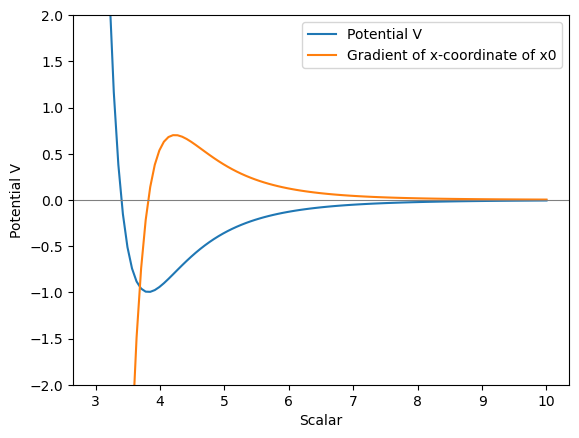

In [69]:
def calculateGradient1(x):
    x0 = np.array([x, 0, 0])
    x1 = np.array([0, 0, 0])
    points = np.array([x0, x1])
    return gradV(points)

print(calculateGradient1(3))

x = np.linspace(3, 10, 100)
y = [calculatePotential1(xi) for xi in x]
dy = [calculateGradient1(xi)[0, 0] for xi in x]

plt.plot(x, y, label='Potential V')
plt.plot(x, dy, label='Gradient of x-coordinate of x0')
plt.axhline(0, color='gray', linewidth=0.8)
plt.ylim(-2, 2)
plt.xlabel('Scalar')
plt.ylabel('Potential V')
plt.legend()
plt.show()

In [71]:
def calculateGradient2(x):
    x0 = np.array([x, 0, 0])
    x1 = np.array([0, 0, 0])
    x2 = np.array([14, 0, 0])
    x3 = np.array([7, 3.2, 0])
    points = np.array([x0, x1, x2, x3])
    return gradV(points)

x = np.linspace(3, 11, 100)
y = [calculatePotential2(xi) for xi in x]
x_min = x[np.argmin(y)]

print(f"x_min={x_min}")
print()
print(calculateGradient2(x_min))

x_min=3.9696969696969697

[[ 0.03937702 -0.48091795  0.        ]
 [-0.51949056 -0.00947811  0.        ]
 [ 0.02469881 -0.00947811  0.        ]
 [ 0.45541473  0.49987417  0.        ]]


### Exercise f)

*Line Searching* moves every particle at once along the direction $\mathbf{d}$, going over the many configurations for $\mathbf{X}_0 + \alpha \mathbf{d}$ to find a minimum. In the case of this exercise, our alpha is contained within $\alpha \in [0,1]$ and our objective is to find the point along the line that makes $\mathbf{d} \cdot \mathbf{F}(\mathbf{X}_0 + \alpha \mathbf{d}) = 0$.

For this, we utilize the bisection solver from exercise b) to find the zero in the aforementioned function, given the limits $[0,\alpha_{max}]$ which we define to be $\alpha_{max} = 1$. With this perspective in mind, the implementation is actually super simple and can be found in `linesearch` below.

Running this on `F=gradV`, $\mathbf{d} = -\nabla V_{LJ} (\mathbf{X}_0)$ where $\mathbf{X}_0$ is the stacked matrix of our particle positions:

$$\mathbf{X}_0 = \begin{bmatrix} 4&0&0 \\\ 0&0&0 \\\ 14&0&0 \\\ 7&3.2&0 \end{bmatrix}$$

We obtain a minimum $\mathbf{d} \cdot \mathbf{F}(\mathbf{X}_0 + \alpha \mathbf{d}) \approx 3.11^{-13}$ at $\alpha = 0.45170705184222015$ after 44 calls.

Despite it still not being a global minimum, the direction among this line (at least for $\alpha \in [0,1]$) as reached as low as possible, meaning that to continue our search, we would need to change $\mathbf{d}$ given the updated gradient.

In [84]:
def linesearch(F, X0, d, alpha_max, tolerance, max_iterations):

    def g(alpha):
        return np.sum(d * F(X0 + alpha * d))

    return bisection_root(g, 0, alpha_max, tolerance)

X0 = np.array([[4,0,0], 
               [0,0,0],
               [14,0,0],
               [7,3.2,0],
               ])
d = -gradV(X0)

alpha, ncalls = linesearch(gradV, X0, d, 1, 1e-13, 100)
print(f"alpha={alpha}, ncalls={ncalls}")
print(f"d*F(X0 + alpha*d)={np.sum(d * gradV(X0 + alpha * d)):2e}")

print()
print(f"V(X0)={V(X0)}, V(X0 + alpha*d)={V(X0 + alpha * d)}")

alpha=0.45170705184222015, ncalls=44
d*F(X0 + alpha*d)=3.107514e-13

V(X0)=-1.6816165088677426, V(X0 + alpha*d)=-2.0023924049321487
